# Notebook Regularización

En este notebook exploramos varias técnicas de regularización y estabilización —dropout, weight decay (L2), data augmentation, batch normalization y early stopping— usando MNIST, ya lo hemos usado antes. 

El objetivo es observar **cómo cambian** la curva de entrenamiento y la brecha entre error de entrenamiento y error de validación/test.  


### Dispositivo y reproducibilidad

Detectamos automáticamente el mejor dispositivo disponible (CUDA > MPS > CPU) y fijamos una semilla global para `numpy`, `random` y `torch` con `set_seed()`.  
**Notas prácticas:**
- `torch.manual_seed()` ayuda mucho, pero reproducibilidad total en GPU puede requerir desactivar ciertas optimizaciones (`torch.backends.cudnn.deterministic=True`) a costa de velocidad.
- Si trabajas en Colab/GPU recuerda que ejecuciones en distintos runtimes o diferentes drivers pueden producir pequeñas diferencias numéricas.



In [1]:
# Notebook: Regularización práctica con una MLP en MNIST (PyTorch)
# ---------------------------------------------------------------
# Requisitos: torch, torchvision, matplotlib, numpy
# En Colab: !pip install -q torch torchvision
# ---------------------------------------------------------------

import os, time, copy
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
import torchvision
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
sns.set()
import tempfile  

# -------------------------
# Device detection (CUDA / MPS / CPU)
# -------------------------
def get_device():
    """
    Detecta el mejor device disponible en este orden:
      1) CUDA (NVIDIA)
      2) MPS  (Apple Silicon)
      3) CPU
    Retorna un torch.device.
    """
    # 1) verificar CUDA
    if torch.cuda.is_available():
        return torch.device("cuda")
    # 2) verificar MPS (Apple)
    mps = getattr(torch.backends, "mps", None)
    if mps is not None and mps.is_available():
        return torch.device("mps")
    # 3) fallback CPU
    return torch.device("cpu")

device = get_device()
print("Usando device:", device)

# -------------------------
# Reproducibilidad (semilla)
# -------------------------
def set_seed(seed=42):
    """
    Fija semillas para numpy, random (stdlib) y torch.
    Esto ayuda a reproducir resultados en la misma máquina.
    Notas:
      - En GPU pueden existir fuentes de no-determinismo (cuDNN, etc.)
      - Para reproducibilidad estricta adicional hay que fijar flags de cuDNN.
    """
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    # si hay CUDA, fijar semillas para todos los dispositivos CUDA
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # para MPS (Apple) en general torch.manual_seed suele ser suficiente
    # no añadimos llamadas específicas a MPS aquí

# fijar semilla por defecto (puedes cambiar el número en la celda superior si quieres experimentos con varias semillas)
set_seed(42)

Usando device: mps


### Dataloaders y Data Augmentation

- El pipeline por defecto usa `ToTensor()` y `Normalize()` (media/desviación estándar de MNIST).
- `use_augmentation=True` aplica transformaciones leves (affine + rotación) que aumentan la variabilidad del train set sin destruir los dígitos.
- `train_size` permite experimentar con escenarios de *pocos datos* para ver el efecto de regularización (overfitting más pronunciado).

In [2]:
# -------------------------
# 1) Dataloaders (MNIST)
#    - transform baseline: ToTensor + Normalize
#    - augmentation option: small affine/rotation + random erasing
# Note: incluso para una MLP, aumentar imágenes puede ayudar la generalización.
# -------------------------

def get_dataloaders(batch_size=64,
                           use_augmentation=False,
                           train_size=None,
                           data_root_env_var='MNIST_DATA_DIR',
                           download=True,
                           seed=42):
    """
    Devuelve: train_loader, val_loader, test_loader (DataLoader).
    Estrategia simple y robusta:
      1) Si la variable de entorno MNIST_DATA_DIR existe y es una ruta, la usamos (supone que es escribible).
      2) Si no existe, NO intentamos crear './data' (evita OSError en FS read-only).
         En su lugar creamos un directorio temporal escribible con tempfile.mkdtemp(...) y lo usamos.
    Esto evita por completo la rama que falla en sistemas con filesystem read-only.
    """
    # Transforms básicos (estándar MNIST)
    normalize = transforms.Normalize((0.1307,), (0.3081,))
    base_tfm = transforms.Compose([transforms.ToTensor(), normalize])

    if use_augmentation:
        train_tfm = transforms.Compose([
            transforms.RandomAffine(degrees=10, translate=(0.08,0.08), scale=(0.95,1.05)),
            transforms.RandomRotation(degrees=10),
            transforms.ToTensor(),
            normalize
        ])
    else:
        train_tfm = base_tfm

    # Decide data_root: prefer env var si está definida y no vacía
    env_path = os.environ.get(data_root_env_var, None)
    if env_path:
        data_root = os.path.expanduser(env_path)
        print(f"[info] Usando MNIST_DATA_DIR del entorno: {data_root}")
    else:
        # NO intentamos crear './data' directamente: elegimos un temp dir siempre.
        data_root = tempfile.mkdtemp(prefix='mnist_data_')
        print(f"[warning] No se encontró MNIST_DATA_DIR; usando directorio temporal escribible: {data_root}")

    # Chequeo simple si el dataset ya está procesado (opcional)
    processed_train = os.path.join(data_root, 'MNIST', 'processed', 'training.pt')
    processed_test  = os.path.join(data_root, 'MNIST', 'processed', 'test.pt')
    mnist_present = os.path.exists(processed_train) and os.path.exists(processed_test)
    if not mnist_present and not download:
        raise FileNotFoundError(f"MNIST no está presente en {data_root} y download=False. Poner download=True o proveer los archivos allí.")

    # Cargar/descargar MNIST (torchvision gestiona la descarga si es necesario)
    # Nota: si el entorno no tiene Internet, la descarga fallará.
    train_full = datasets.MNIST(root=data_root, train=True, download=download, transform=train_tfm)
    test_set   = datasets.MNIST(root=data_root, train=False, download=download, transform=base_tfm)

    # split train/val (90/10) o submuestreo si train_size está dado
    if train_size is not None:
        rng = np.random.RandomState(seed)
        if train_size >= len(train_full):
            train_subset = train_full
        else:
            indices = rng.choice(len(train_full), size=train_size, replace=False)
            train_subset = Subset(train_full, indices)
        # validación: tomamos una porción del train original con transform de test
        train_full_for_val = datasets.MNIST(root=data_root, train=True, download=False, transform=base_tfm)
        n_total = len(train_full_for_val)
        n_val = max(500, int(0.1 * n_total))
        val_indices = list(range(n_total - n_val, n_total))
        val_subset = Subset(train_full_for_val, val_indices)
    else:
        n = len(train_full)
        n_val = int(0.1 * n)
        n_train = n - n_val
        generator = torch.Generator().manual_seed(seed)
        train_subset, val_subset = random_split(train_full, [n_train, n_val], generator=generator)

    # DataLoaders sencillos (num_workers=0 para máxima compatibilidad)
    num_workers = 0
    pin_memory = torch.cuda.is_available()
    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=pin_memory)
    val_loader   = DataLoader(val_subset,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=pin_memory)
    test_loader  = DataLoader(test_set,     batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=pin_memory)

    # Info
    try:
        print(f"[info] data_root efectiva: {data_root}")
        print(f"[info] Train samples: {len(train_subset)}, Val samples: {len(val_subset)}, Test samples: {len(test_set)}")
    except Exception:
        print("[info] Data loaders creados (no se pudo imprimir longitudes).")

    return train_loader, val_loader, test_loader


### Red Neuronal Profunda 

Esta celda define una red neuronal profunda con las siguientes características:
- `input_dim`: tamaño del vector de entrada (para MNIST = 28×28 = 784).
- `hidden_sizes`: lista con el número de neuronas por capa oculta (p. ej. `[512,256,128]`).
- `dropout_p`: probabilidad de dropout (aplicada **después** de la activación de cada capa oculta salvo la última).
- `use_batchnorm`: si es `True` se inserta `BatchNorm1d` justo después de cada `Linear` y antes de la activación `ReLU`.

**Notas prácticas:**
- Colocar `BatchNorm` **antes** de la activación es la práctica más común y estabiliza la distribución de activaciones.
- En la implementación recomendamos **no** poner `Dropout` inmediatamente antes del clasificador final (por eso el `i < len(hidden_sizes)-1`).
- `count_parameters(model)` es una función auxiliar útil para reportar la capacidad del modelo.

In [3]:
# -------------------------
# 2) MLP profundo (DeepMLP)
#    - número configurable de capas ocultas
#    - opción dropout y batchnorm
# -------------------------
import torch.nn as nn
import copy
import time

class DeepMLP(nn.Module):
    def __init__(self, input_dim=28*28, hidden_sizes=[512,256,128], num_classes=10,
                 dropout_p=0.0, use_batchnorm=False):
        """
        MLP totalmente conectada configurable.

        Parámetros:
          - input_dim: dimensión de entrada (MNIST: 28*28)
          - hidden_sizes: lista con tamaño de cada capa oculta (ej. [512,256,128])
          - num_classes: número de clases de salida (10 para MNIST)
          - dropout_p: probabilidad de dropout aplicada **después** de cada activación (si > 0)
          - use_batchnorm: si True aplica BatchNorm1d entre Linear y Activación

        Implementación:
          - Construimos una lista de capas (nn.Sequential) iterando por hidden_sizes.
          - Nota: colocamos BatchNorm1d justo después del Linear y antes de ReLU, siguiendo práctica común.
          - Finalmente añadimos la capa final Linear(in_last_hidden, num_classes).
        """
        super().__init__()
        layers = []
        in_dim = input_dim

        # Construcción dinámica de las capas ocultas
        for i, h in enumerate(hidden_sizes):
            # Capa lineal de in_dim -> h
            layers.append(nn.Linear(in_dim, h))

            # BatchNorm1d (aplica en features, útil para estabilizar activaciones)
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))

            # Activación no lineal (ReLU)
            layers.append(nn.ReLU(inplace=True))

            # Dropout después de la activación (salvo si queremos evitar en la última capa oculta)
            # CORRECCIÓN: la condición original "i < len(hidden_sizes)" incluye la última capa,
            # lo que hace que se aplique Dropout también después de la última oculta (antes del clasificador).
            # Si queremos evitar Dropout justo antes del clasificador, deberíamos usar:
            #    if dropout_p > 0 and i < len(hidden_sizes)-1:
            # Aquí aplicamos Dropout en todas las capas ocultas excepto la última (recomendado).
            if dropout_p > 0 and i < len(hidden_sizes) - 1:
                layers.append(nn.Dropout(dropout_p))

            # actualizar dimensión de entrada para la próxima capa
            in_dim = h

        # Capa final de clasificación (sin activación)
        layers.append(nn.Linear(in_dim, num_classes))

        # Convertir la lista de capas en un Sequential
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        """
        Forward:
         - x tiene forma [B, 1, 28, 28] para imágenes MNIST
         - aplanamos a [B, input_dim] y pasamos por la red completamente conectada
        """
        x = x.view(x.size(0), -1)  # flatten batch
        return self.net(x)

# Snippet adicional (útil en notebook): contar parámetros
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)




In [4]:
# Corre esto para asegurarte que entendiste y que el código corre: 
model = DeepMLP(input_dim=28*28, hidden_sizes=[512,256,128], dropout_p=0.5, use_batchnorm=True).to(device)
print("Parámetros entrenables:", count_parameters(model))
model

Parámetros entrenables: 569226


DeepMLP(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.5, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Linear(in_features=128, out_features=10, bias=True)
  )
)

### Utilidades de entrenamiento

Este bloque define funciones reutilizables para el entrenamiento:

- `train_one_epoch(model, loader, optimizer, criterion)`: ejecuta el bucle de entrenamiento en un epoch:
  - activa `model.train()` (Dropout y BatchNorm en modo entrenamiento),
  - calcula `loss.backward()` y `optimizer.step()`,
  - acumula pérdida sumada por ejemplos y accuracy.

- `evaluate(model, loader, criterion)`: evalúa en modo `model.eval()` sin gradientes (no actualiza parámetros),
  devuelve pérdida media por ejemplo y accuracy.

- `fit(...)`: bucle completo que itera `epochs` veces, llama a `train_one_epoch` y `evaluate`, guarda historial,
  implementa `early_stopping` opcional basado en `val_loss` y devuelve el `model` cargado con los pesos que tuvieron la mejor `val_loss`.

**Detalles importantes / recomendaciones:**
- `early_stopping={'patience':5, 'min_delta':1e-4}` para detener el entrenamiento cuando la mejora se estanca.
- `optimizer` sugerido: `optim.SGD(model.parameters(), lr=0.01, momentum=0.9)` o `optim.Adam(model.parameters(), lr=1e-3)`.
- Vigila `num_workers` y `pin_memory` en `DataLoader` según tu entorno (notebook/Colab/servidor).


In [5]:
# -------------------------
# 3) Utilities de entrenamiento (train_one_epoch, evaluate, fit con early stopping)
# -------------------------

def train_one_epoch(model, loader, optimizer, criterion):
    """
    Una pasada por todos los minibatches del loader de entrenamiento.
    Devuelve: (pérdida media por ejemplo, accuracy)
    Notas:
      - model.train() activa comportamiento de entrenamiento (Dropout, BatchNorm en modo train).
      - calculamos loss.item()*batch_size para promediar correctamente por número de ejemplos.
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)               # forward
        loss = criterion(logits, yb)     # cross-entropy u otra loss
        loss.backward()                  # backprop
        optimizer.step()                 # update params

        # métricas agregadas
        running_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()
        total += xb.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion):
    """
    Evaluación sin gradientes (modo eval).
    Devuelve: (pérdida media por ejemplo, accuracy)
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            running_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)
    return running_loss / total, correct / total


def fit(model, train_loader, val_loader, optimizer, criterion,
        epochs=30, early_stopping=None, verbose=True):
    """
    Bucle de entrenamiento completo con opción de early stopping.

    Parámetros:
      - early_stopping: dict{'patience':int, 'min_delta':float} o None.
        Si está seteado, se hará early stopping cuando la val_loss no mejore
        por 'patience' épocas (mejora definida como reducción > min_delta).
      - verbose: si True imprime resumen cada 5 épocas.
    Retorna:
      - history: dict con listas ['train_loss','train_acc','val_loss','val_acc']
      - model con mejores pesos según val_loss
    """
    history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
    best_val_loss = float('inf')
    best_weights = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0

    for ep in range(1, epochs+1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history['train_loss'].append(tr_loss); history['train_acc'].append(tr_acc)
        history['val_loss'].append(val_loss); history['val_acc'].append(val_acc)

        # Early stopping logic: comprobamos mejora significativa
        delta = early_stopping['min_delta'] if early_stopping else 0.0
        if val_loss < best_val_loss - delta:
            best_val_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if verbose and (ep == 1 or ep % 5 == 0):
            print(f"Epoch {ep}/{epochs} | tr_loss {tr_loss:.4f} tr_acc {tr_acc:.3f} | val_loss {val_loss:.4f} val_acc {val_acc:.3f} | time {time.time()-t0:.2f}s")

        if early_stopping and epochs_no_improve > early_stopping['patience']:
            if verbose:
                print(f"Early stopping at epoch {ep} (no improvement for {epochs_no_improve} epochs)")
            break

    # restaurar mejores pesos observados en validación
    model.load_state_dict(best_weights)
    return history, model


### Runner de experimentos

Esta celda define `run_experiment(cfg)`, una función que:
- fija semilla por experimento (`seed`) para reproducibilidad,
- construye dataloaders (posible submuestreo `train_size` para small-data),
- instancia el modelo `DeepMLP` con la arquitectura solicitada,
- entrena con `fit(...)` (opcional early stopping),
- evalúa en test y devuelve un diccionario con `history`, `model`, métricas y metadatos.

**Regresa lo siguiente:**
- imprime número de parámetros del modelo,
- mide tiempo de entrenamiento por experimento,
- opción para persistir resultados en disco (`save_result`, `save_dir`).


In [6]:
# -------------------------
# 4) Experiment runner
# -------------------------
def run_experiment(cfg):
    """
    Ejecuta un experimento completo definido por el diccionario cfg y devuelve resultados.
    cfg: dict con claves (posibles):
      - name (str): nombre amigable del experimento
      - hidden_sizes (list): arquitectura del MLP
      - dropout_p (float)
      - weight_decay (float)  # L2
      - use_batchnorm (bool)
      - use_augmentation (bool)
      - lr, epochs, batch_size
      - train_size (int or None): submuestreo para small-data
      - early_stopping (dict or None)
      - verbose (bool)
      - seed (int) opcional: semilla para reproducibilidad del experimento
    Retorna: dict con 'cfg', 'history', 'model', 'test_loss', 'test_acc'
    """
    print("\n=== RUN:", cfg.get('name', '<unnamed>'), "===")

    # ---- reproducibilidad por experimento ----
    seed = cfg.get('seed', 42)
    set_seed(seed)  # fija seeds numpy/random/torch (do well before dataloaders/model init)

    # ---- dataloaders ----
    train_loader, val_loader, test_loader = get_dataloaders(
        batch_size=cfg.get('batch_size', 128),
        use_augmentation=cfg.get('use_augmentation', False),
        train_size=cfg.get('train_size', None)
    )

    # ---- instanciar modelo ----
    model = DeepMLP(
        input_dim=28*28,
        hidden_sizes=cfg.get('hidden_sizes', [512,256,128]),
        dropout_p=cfg.get('dropout_p', 0.0),
        use_batchnorm=cfg.get('use_batchnorm', False)
    ).to(device)

    # mostrar número de parámetros (útil para reportes)
    n_params = count_parameters(model)
    print(f"Modelo: {cfg.get('name','model')} | params: {n_params:,d}")

    # ---- optimizador y criterio ----
    # SGD + momentum se recomienda para reproducibilidad tipo "SGD-ish"; weight_decay == L2
    optimizer = optim.SGD(model.parameters(),
                          lr=cfg.get('lr', 0.01),
                          momentum=0.9,
                          weight_decay=cfg.get('weight_decay', 0.0))
    criterion = nn.CrossEntropyLoss()

    # ---- entrenar ----
    t0 = time.time()
    hist, best_model = fit(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        epochs=cfg.get('epochs', 30),
        early_stopping=cfg.get('early_stopping', None),
        verbose=cfg.get('verbose', True)
    )
    elapsed = time.time() - t0
    print(f"Finished training in {elapsed:.1f}s")

    # ---- evaluación final en test ----
    test_loss, test_acc = evaluate(best_model, test_loader, criterion)
    print(f"Test -> loss: {test_loss:.4f} acc: {test_acc:.4f}")

    # ---- paquete resultado ----
    result = {
        'cfg': cfg,
        'history': hist,
        'model': best_model,
        'test_loss': test_loss,
        'test_acc': test_acc,
        'n_params': n_params,
        'seed': seed,
    }

    # opcional: persistir resultado en disco (pickle) para análisis posterior
    if cfg.get('save_result', False):
        import pickle, pathlib
        outdir = pathlib.Path(cfg.get('save_dir','./results'))
        outdir.mkdir(parents=True, exist_ok=True)
        fname = outdir / f"{cfg.get('name','exp')}_seed{seed}.pkl"
        with open(fname, 'wb') as f:
            pickle.dump(result, f)
        print(f"Saved result to {fname}")

    return result


### Configuración de experimentos

- `base_cfg` define los hiperparámetros por defecto.
- Cada entrada en la lista `experiments` sobreescribe campos relevantes (p. ej. activar BatchNorm o Dropout).
- **Advertencia:** ejecutar todos los experiments con `epochs=60` en CPU puede tardar mucho; puedes reducir el número de `epochs` a 10-20 o solo ejecutar un subconjunto de experimentos en tu máeuina 
- Puedes marcar un experimento para **saltar** añadiendo `'skip': True` en el dict (útil para mantener la lista completa pero no correr todo en el demo en vivo).


In [7]:
# -------------------------
# 5) Configure & run experiments (lista de configuraciones)
# -------------------------
# CUIDADO: correr todos los experimentos en tu CPU con 60 epochs probablemente lo va a matar, reduce la cantidad de epochs
# o correr solo 1 experimento 
base_cfg = {
    'hidden_sizes':[512,256,128],
    'dropout_p':0.0,
    'weight_decay':0.0,
    'use_batchnorm':False,
    'use_augmentation':False,
    'lr':0.01,
    'epochs':30,
    'batch_size':128,
    'train_size': None,   # None usa todo el train set de MNIST
    'early_stopping': None,
    'verbose': True,
    'seed': 42,
    'save_result': False,  # si True guarda pickle en save_dir
    'save_dir': './results'
}

# Lista de experimentos planificados
experiments = []
experiments.append({**base_cfg, 'name':'baseline'})  # no regularización
experiments.append({**base_cfg, 'name':'weight_decay', 'weight_decay':1e-3})
experiments.append({**base_cfg, 'name':'dropout_0.5', 'dropout_p':0.5})
experiments.append({**base_cfg, 'name':'batchnorm', 'use_batchnorm':True})
experiments.append({**base_cfg, 'name':'augmentation', 'use_augmentation':True})
# small-data demonstration: subsample train set (muestra overfitting)
experiments.append({**base_cfg, 'name':'small_data_baseline', 'train_size':2000, 'epochs':60})
experiments.append({**base_cfg, 'name':'small_data_reg', 'train_size':2000, 'weight_decay':1e-3, 'dropout_p':0.5, 'epochs':60})
# early stopping ejemplo (más epochs pero con paciencia)
experiments.append({**base_cfg, 'name':'early_stopping', 'epochs':80, 'early_stopping':{'patience':6,'min_delta':1e-4}})

# Sugerencia: para demos en vivo reduce la lista o epochs
results = []
for cfg in experiments:
    # pequeña protección: permitir saltar experimentos pesados (ideal para notebooks interactivos)
    if cfg.get('skip', False):
        print(f"Skipping {cfg['name']}")
        continue
    res = run_experiment(cfg)
    results.append(res)


=== RUN: baseline ===
[warning] No se encontró MNIST_DATA_DIR; usando directorio temporal escribible: /var/folders/sd/dkyxscds0nj6_vpftw74_csr0000gn/T/mnist_data_0mdl80jg


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.98MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 307kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.72MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.31MB/s]


[info] data_root efectiva: /var/folders/sd/dkyxscds0nj6_vpftw74_csr0000gn/T/mnist_data_0mdl80jg
[info] Train samples: 54000, Val samples: 6000, Test samples: 10000
Modelo: baseline | params: 567,434
Epoch 1/30 | tr_loss 0.5702 tr_acc 0.840 | val_loss 0.2180 val_acc 0.933 | time 5.04s
Epoch 5/30 | tr_loss 0.0521 tr_acc 0.984 | val_loss 0.0923 val_acc 0.972 | time 3.39s
Epoch 10/30 | tr_loss 0.0102 tr_acc 0.998 | val_loss 0.0885 val_acc 0.975 | time 3.33s
Epoch 15/30 | tr_loss 0.0014 tr_acc 1.000 | val_loss 0.0826 val_acc 0.979 | time 3.32s
Epoch 20/30 | tr_loss 0.0006 tr_acc 1.000 | val_loss 0.0883 val_acc 0.979 | time 3.31s
Epoch 25/30 | tr_loss 0.0004 tr_acc 1.000 | val_loss 0.0920 val_acc 0.979 | time 3.31s
Epoch 30/30 | tr_loss 0.0003 tr_acc 1.000 | val_loss 0.0944 val_acc 0.979 | time 3.32s
Finished training in 101.7s
Test -> loss: 0.0654 acc: 0.9807

=== RUN: weight_decay ===
[warning] No se encontró MNIST_DATA_DIR; usando directorio temporal escribible: /var/folders/sd/dkyxscds0n

100%|██████████| 9.91M/9.91M [00:01<00:00, 8.76MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 310kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.62MB/s]


[info] data_root efectiva: /var/folders/sd/dkyxscds0nj6_vpftw74_csr0000gn/T/mnist_data_ixj035b9
[info] Train samples: 54000, Val samples: 6000, Test samples: 10000
Modelo: weight_decay | params: 567,434
Epoch 1/30 | tr_loss 0.5737 tr_acc 0.839 | val_loss 0.2218 val_acc 0.932 | time 3.51s
Epoch 5/30 | tr_loss 0.0601 tr_acc 0.982 | val_loss 0.0936 val_acc 0.971 | time 3.28s
Epoch 10/30 | tr_loss 0.0227 tr_acc 0.995 | val_loss 0.0736 val_acc 0.977 | time 3.30s
Epoch 15/30 | tr_loss 0.0118 tr_acc 0.998 | val_loss 0.0700 val_acc 0.977 | time 3.31s
Epoch 20/30 | tr_loss 0.0099 tr_acc 0.999 | val_loss 0.0701 val_acc 0.977 | time 3.53s
Epoch 25/30 | tr_loss 0.0089 tr_acc 1.000 | val_loss 0.0680 val_acc 0.979 | time 3.27s
Epoch 30/30 | tr_loss 0.0084 tr_acc 1.000 | val_loss 0.0663 val_acc 0.980 | time 3.25s
Finished training in 100.6s
Test -> loss: 0.0580 acc: 0.9819

=== RUN: dropout_0.5 ===
[warning] No se encontró MNIST_DATA_DIR; usando directorio temporal escribible: /var/folders/sd/dkyxscd

...

[info] data_root efectiva: /var/folders/sd/dkyxscds0nj6_vpftw74_csr0000gn/T/mnist_data_tczwelfs
[info] Train samples: 2000, Val samples: 6000, Test samples: 10000
Modelo: small_data_baseline | params: 567,434
Epoch 1/60 | tr_loss 2.2837 tr_acc 0.217 | val_loss 2.2478 val_acc 0.392 | time 0.47s
Epoch 5/60 | tr_loss 0.7561 tr_acc 0.774 | val_loss 0.5652 val_acc 0.832 | time 0.41s
Epoch 10/60 | tr_loss 0.2568 tr_acc 0.927 | val_loss 0.3144 val_acc 0.909 | time 0.42s
Epoch 15/60 | tr_loss 0.1432 tr_acc 0.962 | val_loss 0.2867 val_acc 0.919 | time 0.42s
Epoch 20/60 | tr_loss 0.0678 tr_acc 0.986 | val_loss 0.2897 val_acc 0.919 | time 0.41s
Epoch 25/60 | tr_loss 0.0301 tr_acc 0.998 | val_loss 0.2825 val_acc 0.929 | time 0.42s
Epoch 30/60 | tr_loss 0.0151 tr_acc 1.000 | val_loss 0.3054 val_acc 0.929 | time 0.43s
Epoch 35/60 | tr_loss 0.0095 tr_acc 1.000 | val_loss 0.3139 val_acc 0.929 | time 0.43s
Epoch 40/60 | tr_loss 0.0067 tr_acc 1.000 | val_loss 0.3283 val_acc 0.929 | time 0.42s
Epoch 45/6

100%|██████████| 9.91M/9.91M [00:01<00:00, 7.48MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 312kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.65MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.05MB/s]


[info] data_root efectiva: /var/folders/sd/dkyxscds0nj6_vpftw74_csr0000gn/T/mnist_data_y2_89wmk
[info] Train samples: 2000, Val samples: 6000, Test samples: 10000
Modelo: small_data_reg | params: 567,434
Epoch 1/60 | tr_loss 2.2928 tr_acc 0.127 | val_loss 2.2646 val_acc 0.342 | time 0.45s
Epoch 5/60 | tr_loss 1.3751 tr_acc 0.582 | val_loss 0.8880 val_acc 0.781 | time 0.42s
Epoch 10/60 | tr_loss 0.4963 tr_acc 0.840 | val_loss 0.3714 val_acc 0.887 | time 0.42s
Epoch 15/60 | tr_loss 0.3117 tr_acc 0.900 | val_loss 0.2692 val_acc 0.921 | time 0.42s
Epoch 20/60 | tr_loss 0.2072 tr_acc 0.935 | val_loss 0.2543 val_acc 0.926 | time 0.43s
Epoch 25/60 | tr_loss 0.1404 tr_acc 0.956 | val_loss 0.2433 val_acc 0.933 | time 0.42s
Epoch 30/60 | tr_loss 0.1047 tr_acc 0.973 | val_loss 0.2363 val_acc 0.937 | time 0.42s
Epoch 35/60 | tr_loss 0.0770 tr_acc 0.976 | val_loss 0.2273 val_acc 0.942 | time 0.42s
Epoch 40/60 | tr_loss 0.0582 tr_acc 0.984 | val_loss 0.2254 val_acc 0.942 | time 0.42s
Epoch 45/60 | t

100%|██████████| 9.91M/9.91M [00:01<00:00, 7.93MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 314kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.00MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.15MB/s]


[info] data_root efectiva: /var/folders/sd/dkyxscds0nj6_vpftw74_csr0000gn/T/mnist_data_0pe0kysi
[info] Train samples: 54000, Val samples: 6000, Test samples: 10000
Modelo: early_stopping | params: 567,434
Epoch 1/80 | tr_loss 0.5702 tr_acc 0.840 | val_loss 0.2180 val_acc 0.933 | time 3.31s
Epoch 5/80 | tr_loss 0.0521 tr_acc 0.984 | val_loss 0.0923 val_acc 0.972 | time 3.26s
Epoch 10/80 | tr_loss 0.0102 tr_acc 0.998 | val_loss 0.0885 val_acc 0.975 | time 3.25s
Epoch 15/80 | tr_loss 0.0014 tr_acc 1.000 | val_loss 0.0826 val_acc 0.979 | time 3.27s
Early stopping at epoch 15 (no improvement for 7 epochs)
Finished training in 49.2s
Test -> loss: 0.0654 acc: 0.9807


## Interpretación de las gráficas y la tabla resumen

### Curvas `train_loss` y `val_loss`
- Si `train_loss` baja pero `val_loss` se estanca o sube: **overfitting** (el modelo aprende ruido/peculiaridades del train set).  
- Si ambas curvas bajan y convergen cercanas: buena generalización.  
- Si ambas curvas bajan muy lentamente o `train_loss` no baja: problema de optimización (learning rate muy pequeño, mala inicialización, saturación por activación).

### Curvas `train_acc` y `val_acc`
- El gap `train_acc - val_acc` es una medida directa de sobreajuste en accuracy.  
- Observa si regularizadores (dropout, weight decay, augment) reducen este gap en `small_data` — eso indica que la técnica mejora generalización.

### Tabla resumen
- Ordena por `test_acc` para identificar la mejor corrida.  
- Compara `weight_decay`, `dropout`, `batchnorm` y `augmentation`: normalmente `augmentation` y `batchnorm` aportan grandes beneficios; `weight_decay` y `dropout` son ayudas complementarias, especialmente en `small_data`.

### Sugerencias concretas de diagnóstico
- Si una clase está sistemáticamente mal clasificada: inspecciona ejemplos falsos positivos/negativos para ver si el dataset tiene ruidos o ambigüedad.
- Si la varianza entre runs con distintas semillas es grande en `small_data`, reporta promedio y desviación estándar de `test_acc` sobre varias semillas.


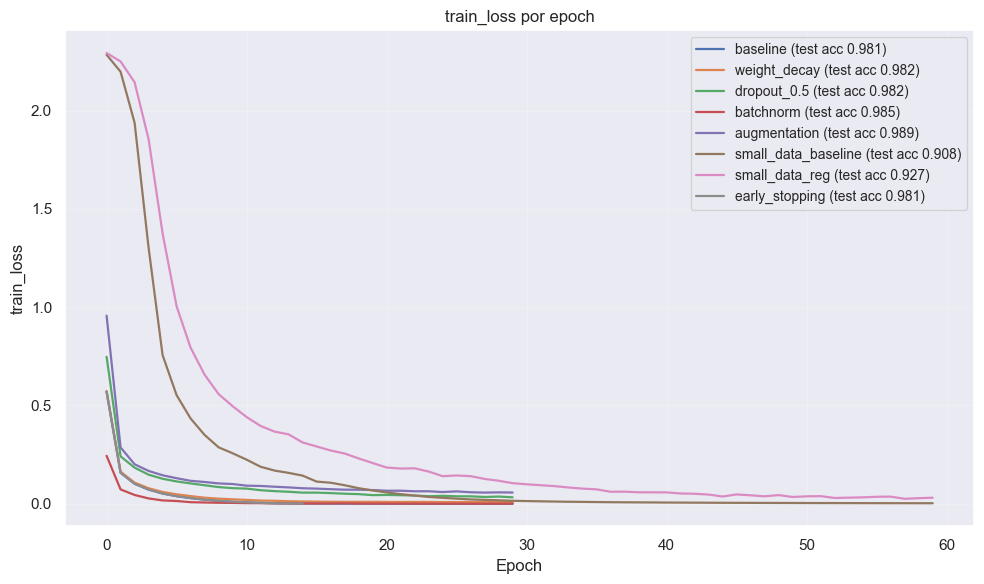

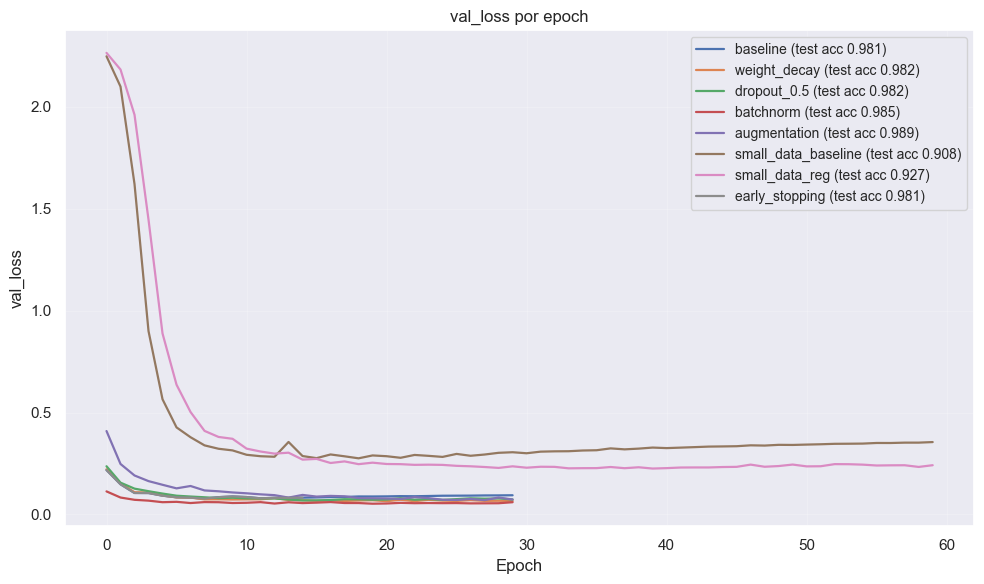

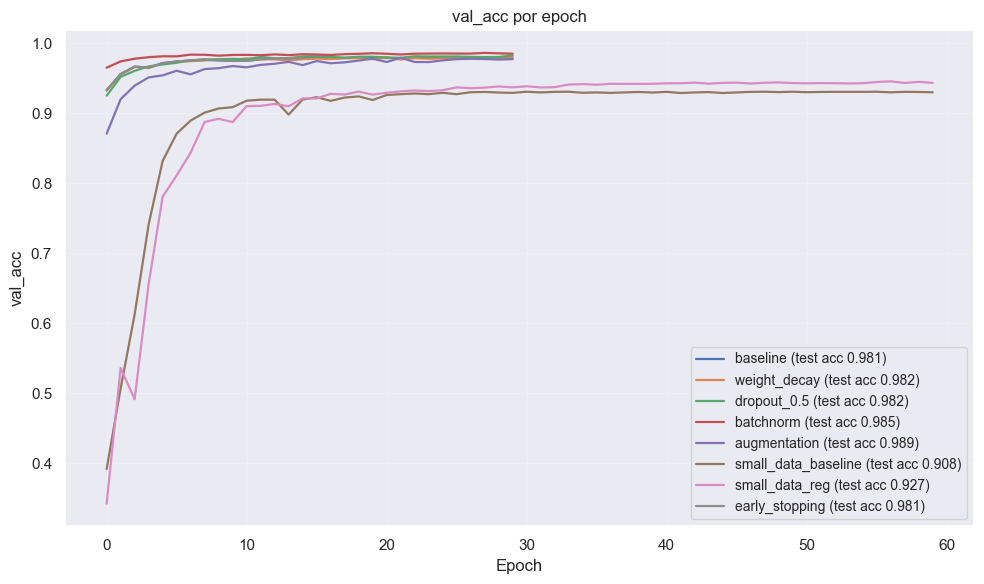


Resumen final (ordenado por test_acc):


,name,test_acc,test_loss,n_params,weight_decay,dropout,batchnorm,augmentation,train_size,seed
0,augmentation,0.9885,0.037031,567434,0.000,0.0,False,True,NaN,42
1,batchnorm,0.9846,0.054047,569226,0.000,0.0,True,False,NaN,42
2,dropout_0.5,0.9821,0.062145,567434,0.000,0.5,False,False,NaN,42
3,weight_decay,0.9819,0.058006,567434,0.001,0.0,False,False,NaN,42
4,baseline,0.9807,0.065387,567434,0.000,0.0,False,False,NaN,42
5,early_stopping,0.9807,0.065387,567434,0.000,0.0,False,False,NaN,42
6,small_data_reg,0.9266,0.290689,567434,0.001,0.5,False,False,2000.0,42
7,small_data_baseline,0.9079,0.346758,567434,0.000,0.0,False,False,2000.0,42


In [8]:
# -------------------------
# 6) Plot and summarize results (comentado y mejorado)
# -------------------------
import pandas as pd
import seaborn as sns

def plot_histories(results, metric='val_loss', smooth=False, sigma=1.0, savefig=None):
    """
    Traza la serie temporal (por epoch) de 'metric' para cada experimento en results.
    - results: lista de dicts retornados por run_experiment(...)
    - metric: 'train_loss' | 'val_loss' | 'train_acc' | 'val_acc'
    - smooth: si True aplica suavizado gaussiano (sólo para presentación)
    - sigma: desviación estándar para el suavizado
    - savefig: path (str) para guardar la figura si no es None
    """
    plt.figure(figsize=(10,6))
    for r in results:
        h = r['history'][metric]
        label = f"{r['cfg']['name']} (test acc {r['test_acc']:.3f})"
        if smooth:
            # importación local para evitar dependencia global en todos los entornos
            from scipy.ndimage import gaussian_filter1d
            y = gaussian_filter1d(np.array(h), sigma=sigma)
        else:
            y = np.array(h)
        plt.plot(y, label=label, linewidth=1.6)
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.title(f"{metric} por epoch")
    plt.legend(loc='best', fontsize='small')
    plt.grid(alpha=0.2)
    plt.tight_layout()
    if savefig:
        plt.savefig(savefig, dpi=200)
        print(f"Saved figure to {savefig}")
    plt.show()

# funciones de plot rápido (llamadas ejemplo)
plot_histories(results, metric='train_loss', smooth=False)
plot_histories(results, metric='val_loss', smooth=False)
plot_histories(results, metric='val_acc', smooth=False)

# -------------------------
# Tabla resumen más legible (pandas)
# -------------------------
def results_summary_table(results):
    """
    Construye un DataFrame con resumen de resultados:
      - name, test_acc, test_loss, n_params, weight_decay, dropout, bn, aug, train_size, seed
    """
    rows = []
    for r in results:
        c = r['cfg']
        rows.append({
            'name': c.get('name'),
            'test_acc': r.get('test_acc'),
            'test_loss': r.get('test_loss'),
            'n_params': r.get('n_params', None),
            'weight_decay': c.get('weight_decay', 0.0),
            'dropout': c.get('dropout_p', 0.0),
            'batchnorm': c.get('use_batchnorm', False),
            'augmentation': c.get('use_augmentation', False),
            'train_size': c.get('train_size', None),
            'seed': c.get('seed', None)
        })
    df = pd.DataFrame(rows)
    # ordenar por test_acc descendente para identificar mejor corridas
    df = df.sort_values(by='test_acc', ascending=False).reset_index(drop=True)
    return df

summary_df = results_summary_table(results)
# mostrar tabla con formato
from IPython.display import display
print("\nResumen final (ordenado por test_acc):")
display(summary_df)

# -------------------------
# Confusion matrix utility mejorada
# -------------------------
def confusion_matrix_for_run(run_idx=None, run_name=None, normalize=True, cmap='Blues'):
    """
    Traza la matriz de confusión para un run seleccionado.
    - run_idx: índice en la lista `results` (si se conoce)
    - run_name: nombre del experimento (si prefieres buscar por nombre)
    - normalize: si True normaliza por fila (recall por clase)
    """
    # seleccionar run
    if run_idx is None and run_name is None:
        raise ValueError("Proporciona run_idx o run_name")
    if run_idx is not None:
        r = results[run_idx]
    else:
        # buscar por nombre (primer match)
        matches = [x for x in results if x['cfg']['name'] == run_name]
        if len(matches) == 0:
            raise ValueError(f"No se encontró experimento con name='{run_name}'")
        r = matches[0]

    model = r['model']
    model.eval()

    # construir test loader con transform de evaluación
    test_loader = get_dataloaders(batch_size=512, use_augmentation=False)[2]

    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            logits = model(xb)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(yb.numpy())
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
    cm = confusion_matrix(all_labels, all_preds)
    if normalize:
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        cm_plot = cm_norm
    else:
        cm_plot = cm

    plt.figure(figsize=(8,6))
    sns.heatmap(cm_plot, annot=True, fmt='.2f' if normalize else 'd', cmap=cmap)
    plt.xlabel('Predicted'); plt.ylabel('True')
    title = f"Confusion matrix - {r['cfg']['name']} (test acc {r['test_acc']:.3f})"
    plt.title(title)
    plt.tight_layout()
    plt.show()

    # additional metrics text
    print("\nClassification report (por clase):\n")
    print(classification_report(all_labels, all_preds, digits=4))
    print("Overall accuracy:", accuracy_score(all_labels, all_preds))




## ¿Qué nos muestran las gráficas y la tabla?

1. Las curvas de `train_loss`:
- Las tres gráficas muestras las mismas series por experimento, las forma general es muy parecida 
- Todas las corridas (baseline, weight_decay, dropout_0.5, batchnorm, augmentation, early_stopping) reducen la pérdida de entrenamiento rápidamente en las primeras ~5–10 épocas y luego se estabilizan muy bajas (~0.0x).
- Los experimentos de small_data (small_data_baseline, small_data_reg) muestran una curva de train_loss más alta y que desciende mucho más lentamente — esto indica que con pocos datos el optimizador tarda más en ajustarse y el modelo presenta menor capacidad de reducir la pérdida con óptimos locales rápidos.
- batchnorm y augmentation tienden a tener curvaturas que bajan rápido y alcanzan pérdidas de entrenamiento bajas de forma robusta; dropout muestra entrenamiento algo más lento (esperable porque dropout introduce ruido), pero al final consigue pérdidas bajas similares.

2. La tabla ordenada por `test_acc`
- Mejor test_acc: augmentation → 0.9897 (mejor resultado de generalización entre los experimentos).
- En segundo lugar dropout_0.5 (0.9848) y batchnorm (0.9843), seguidos por weight_decay (0.9823) y baseline (0.9802). early_stopping coincide con baseline en este run (0.9802).
- Para el caso small_data: sin regularización test_acc = 0.9079; con regularización combinada (weight_decay=1e-3 + dropout=0.5) sube a 0.9261. 
- El número de parámetros (~567k) es grande comparado con 2000 ejemplos: explica por qué small_data sobreajusta con facilidad.

3. Combinando las gráficas y la tabla: 
- Data augmentation aporta la mayor ganancia de generalización. Esto sugiere que el principal problema no es falta de regularizador paramétrico sino la insuficiente diversidad de datos para aprender invariancias útiles — la augmentación provee esa diversidad.
- Dropout y weight decay (L2) mejoran la generalización respecto al baseline, pero en magnitud menos que augmentation. Dropout (0.5) parece dar un buen trade-off (mejor test_acc que weight_decay).
- BatchNorm mejora ligeramente sobre el baseline; su efecto principal suele ser estabilizar/accelerar entrenamiento y permitir lr mayores — aquí da una mejora pequeña pero consistente.
- Early stopping en este experimento no generó una mejora sobre el baseline (idéntico test_acc), lo cual puede deberse a que el baseline ya no estaba sobreentrenando fuertemente o la política de patience/min_delta usada.


## Conclusiones: 

- En este ejemplo la regularización más efectiva fue augmentation: para problemas de computer visión, crear transformaciones coherentes con la invariancia del problema suele ser la forma más potente de mejorar generalización sin cambiar arquitectura ni aumentar parámetros. Expone al modelo a variaciones plausibles de las muestras reales, incrementa la cobertura del espacio de entrada y reduce la varianza del estimador.
- Los regularizadores clásicos ayudan:
     - Dropout (p=0.5) da una mejora clara sobre baseline y es especialmente útil si no puedes aumentar datos. Impide co-adaptación neuronal y fuerza representaciones redundantes más robustas
     - Weight decay también ayuda, reduce ligeramente el overfitting y produce modelos más estables. L2 penaliza magnitudes de pesos (evita pesos extremadamente grandes que memoricen ruido).
- BatchNorm aporta mejoras moderadas y hace el entrenamiento más estable; útil cuando se suben tasas de aprendizaje o cuando se busca una convergencia más suave. Normaliza pre-activaciones (media≈0, var≈1 por mini-batch), mejorando el conditioning del problema y el flujo de gradiente (menor riesgo de saturación y gradientes inestables).
- Escenario small-data: con 2.000 ejemplos el modelo (567k parámetros) esta sobre-parametrizado. Regularización (L2 + dropout) reduce el daño, pero no compensa la falta de datos: la performance final sigue lejos de la del dataset completo.
- Early stopping es una buena práctica, pero su beneficio depende de la dinámica del experimento y de la política de patience/min_delta. No sustituye a buenas augmentaciones o a diseño de red proporcional a los datos.